## Introduction of the code

This project shows an exploratory data analysis (EDA) of a dataframe about the causes of flights delays from various airports in the United States. The main objectives are to identify the carriers and airports with the highest and lowest on-time performance and to analyze the correlations between different variables that cause delay

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data exploration

In [2]:
data = pd.read_csv('Data/Airline_Delay_Cause.csv')
data.head(10)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.00,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.00,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.00,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0
5,2025,1,G4,Allegiant Air,EYW,"Key West, FL: Key West International",73.0,8.0,4.69,0.00,...,0.0,2.88,2.0,0.0,447.0,129.0,0.0,25.0,0.0,293.0
6,2025,1,G4,Allegiant Air,FAR,"Fargo, ND: Hector International",75.0,8.0,4.34,0.00,...,0.0,1.20,0.0,0.0,468.0,340.0,0.0,90.0,0.0,38.0
7,2025,1,G4,Allegiant Air,FAT,"Fresno, CA: Fresno Yosemite International",39.0,12.0,1.55,0.47,...,0.0,7.50,0.0,0.0,838.0,140.0,21.0,210.0,0.0,467.0
8,2025,1,G4,Allegiant Air,FCA,"Kalispell, MT: Glacier Park International",28.0,3.0,1.00,1.00,...,0.0,1.00,0.0,1.0,440.0,299.0,31.0,0.0,0.0,110.0
9,2025,1,G4,Allegiant Air,FLL,"Fort Lauderdale, FL: Fort Lauderdale-Hollywood...",326.0,104.0,22.59,10.79,...,0.0,35.20,3.0,0.0,11093.0,3354.0,2708.0,2029.0,0.0,3002.0


This dataset contains information about airline delays and their causes. Let's explore the structure and summary statistics of the data:

In [3]:
# Display basic info about the DataFrame
data.info()

# Show summary statistics
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190335 entries, 0 to 190334
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 190335 non-null  int64  
 1   month                190335 non-null  int64  
 2   carrier              190335 non-null  object 
 3   carrier_name         190335 non-null  object 
 4   airport              190335 non-null  object 
 5   airport_name         190335 non-null  object 
 6   arr_flights          189990 non-null  float64
 7   arr_del15            189737 non-null  float64
 8   carrier_ct           189990 non-null  float64
 9   weather_ct           189990 non-null  float64
 10  nas_ct               189990 non-null  float64
 11  security_ct          189990 non-null  float64
 12  late_aircraft_ct     189990 non-null  float64
 13  arr_cancelled        189990 non-null  float64
 14  arr_diverted         189990 non-null  float64
 15  arr_delay        

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,190335.000000,190335.000000,189990.000000,189737.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000
mean,2020.390969,6.438674,321.096668,58.350870,18.542072,2.059380,16.805769,0.149036,20.716906,6.602095,0.760572,3932.901784,1355.701200,220.237991,814.166556,7.036012,1535.744787
std,2.439395,3.488701,920.132463,167.154599,48.363146,7.212806,56.169862,0.717362,66.598795,40.621291,3.406992,12576.717863,4336.193396,869.704989,3198.832155,40.952528,5240.233800
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,39.000000,5.000000,1.930000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,286.000000,89.000000,0.000000,27.000000,0.000000,53.000000
50%,2020.000000,6.000000,87.000000,15.000000,5.280000,0.220000,3.240000,0.000000,4.200000,1.000000,0.000000,899.000000,317.000000,12.000000,123.000000,0.000000,283.000000
75%,2022.000000,9.000000,211.000000,39.000000,14.420000,1.630000,9.590000,0.000000,12.930000,3.000000,1.000000,2555.000000,985.000000,134.000000,395.000000,0.000000,972.000000
max,2025.000000,12.000000,21977.000000,5544.000000,1886.580000,325.410000,1884.420000,58.690000,2588.130000,4951.000000,192.000000,648300.000000,321792.000000,64550.000000,139958.000000,3760.000000,279153.000000


In [4]:
print(f'Total missing values in the dataset: {data.isnull().sum()}')
# Drop rows with missing values as they are very low compared to the whole dataset
data = data.dropna()

Total missing values in the dataset: year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            345
arr_del15              598
carrier_ct             345
weather_ct             345
nas_ct                 345
security_ct            345
late_aircraft_ct       345
arr_cancelled          345
arr_diverted           345
arr_delay              345
carrier_delay          345
weather_delay          345
nas_delay              345
security_delay         345
late_aircraft_delay    345
dtype: int64


Dropping data with atypically values of On-time flights.

In [5]:
data['On-time'] = data['arr_flights'] - data['arr_cancelled'] - data['arr_diverted'] - data['arr_del15']
data['On-time_percentage'] = (data['On-time'] / data['arr_flights']) * 100

# Replace infty values
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=['On-time_percentage'], inplace=True)

# Drop atypically values
umbral_cuantil = 0.001

umbral_valor = data['On-time'].quantile(umbral_cuantil)
rows_to_erase = data[data['On-time'] <= umbral_valor]
print(f"rows erased: {len(rows_to_erase)}.")
data = data[data['On-time'] > umbral_valor].copy()

umbral_valor = data['On-time'].quantile(1-umbral_cuantil)
rows_to_erase = data[data['On-time'] >= umbral_valor]
print(f"rows erased: {len(rows_to_erase)}.")
data = data[data['On-time'] < umbral_valor].copy()

rows erased: 592.
rows erased: 190.


This is an aggresive approach since high or low values can show valuable evidence. Nevertheless, in this project we are aiming for better consistency.

In [6]:
# Create a datetime index from year and month columns
try:
    data['date'] = pd.to_datetime(data['year'].astype(str) + '-' + data['month'].astype(str), format='%Y-%m')
    data.set_index('date', inplace=True)
    data.index = data.index.to_period('M')
except:
    print("Error, please check the year and month columns")    

Now we are going to plot some graphs to visualize data from the dataset. This first code shows which is the airport that has more arrival flights.

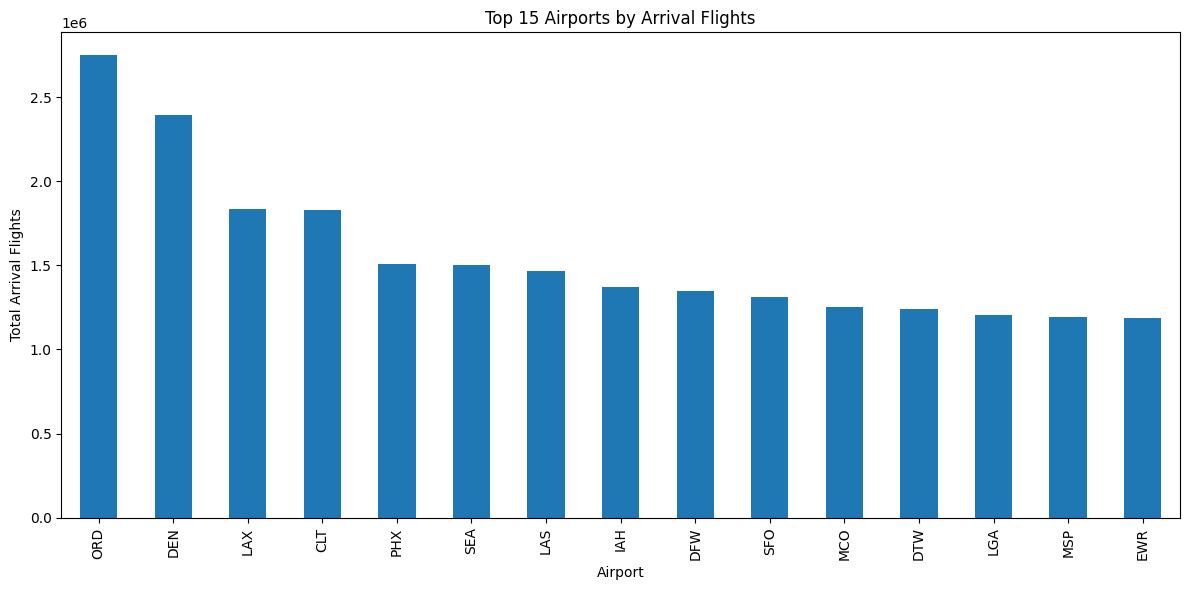

In [7]:
# Group by airport and sum arrival flights
arr_flights_by_airport = data.groupby('airport')['arr_flights'].sum().sort_values(ascending=False)

# Plot the top 10 airports by arrival flights
arr_flights_by_airport.head(15).plot(kind='bar', figsize=(12,6))
plt.title('Top 15 Airports by Arrival Flights')
plt.xlabel('Airport')
plt.ylabel('Total Arrival Flights')
plt.tight_layout()
plt.show()

Now lets show distribution of flight status and the causes of delays. This information can be used to inform measures that improve the quality of airports and reduce delays.

<Figure size 640x480 with 0 Axes>

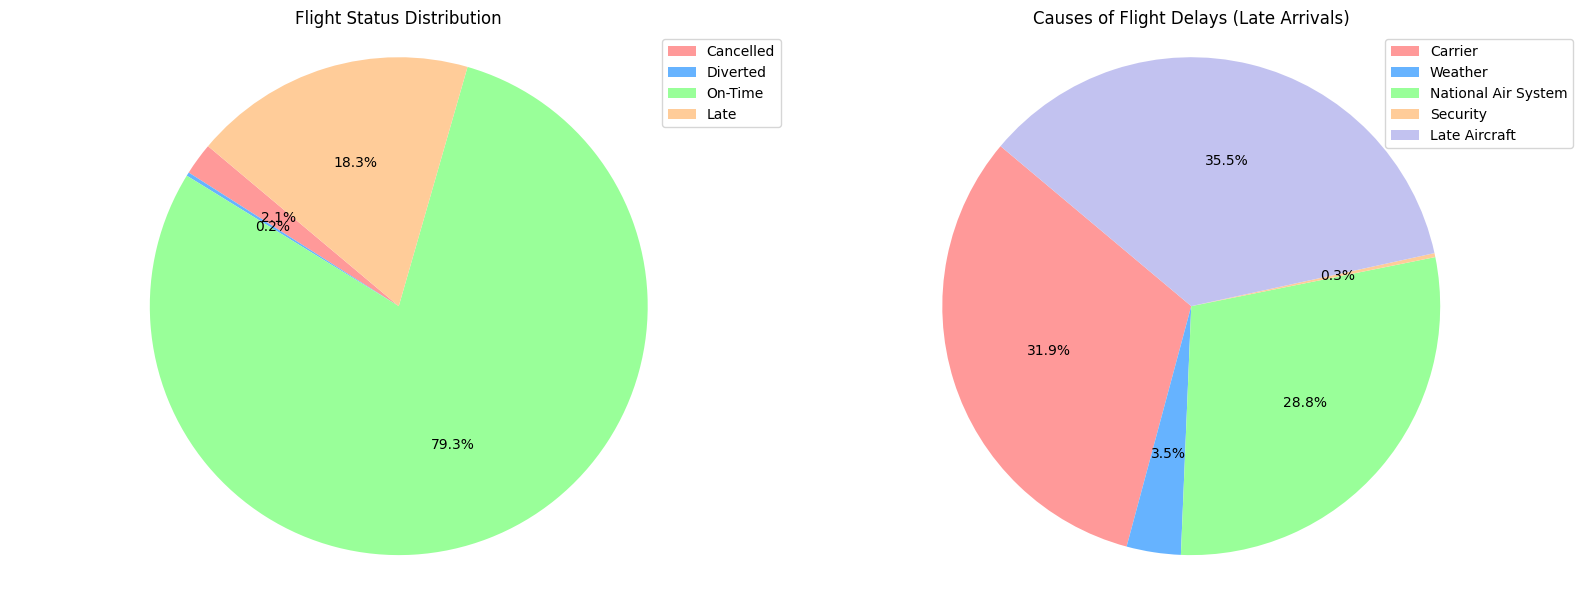

In [8]:
total_flights = data['arr_flights'].sum()
total_cancelled = data['arr_cancelled'].sum()
total_diverted = data['arr_diverted'].sum()
total_late = data['arr_del15'].sum()
total_ok = total_flights - total_cancelled - total_diverted - total_late

# Prepare data for pie chart
labels = ['Cancelled', 'Diverted', 'On-Time', 'Late']
sizes = [total_cancelled, total_diverted, total_ok, total_late]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.tight_layout()
plt.show()
# Calculate total late flights by cause
late_causes = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
late_totals = data[late_causes].sum()

# Prepare labels and colors for the pie chart
cause_labels = ['Carrier', 'Weather', 'National Air System', 'Security', 'Late Aircraft']
cause_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']


# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First pie chart: Flight Status Distribution
axes[0].pie(sizes, autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title('Flight Status Distribution')
axes[0].legend(labels, loc="best")
axes[0].axis('equal')

# Second pie chart: Causes of Flight Delays (Late Arrivals)
axes[1].pie(late_totals, autopct='%1.1f%%', colors=cause_colors, startangle=140)
axes[1].set_title('Causes of Flight Delays (Late Arrivals)')
axes[1].legend(cause_labels, loc="best")
axes[1].axis('equal')

plt.tight_layout()
plt.show()

The subsequent plot offers a ranking comparison of airlines and airports, utilizing the percentage distribution of on-time flights as the key metric. The resulting data not only aids passengers in optimizing their travel choices but is also beneficial for the carriers and airports themselves. Specifically, a lower position on this list serves as an indicator that service enhancements are required.

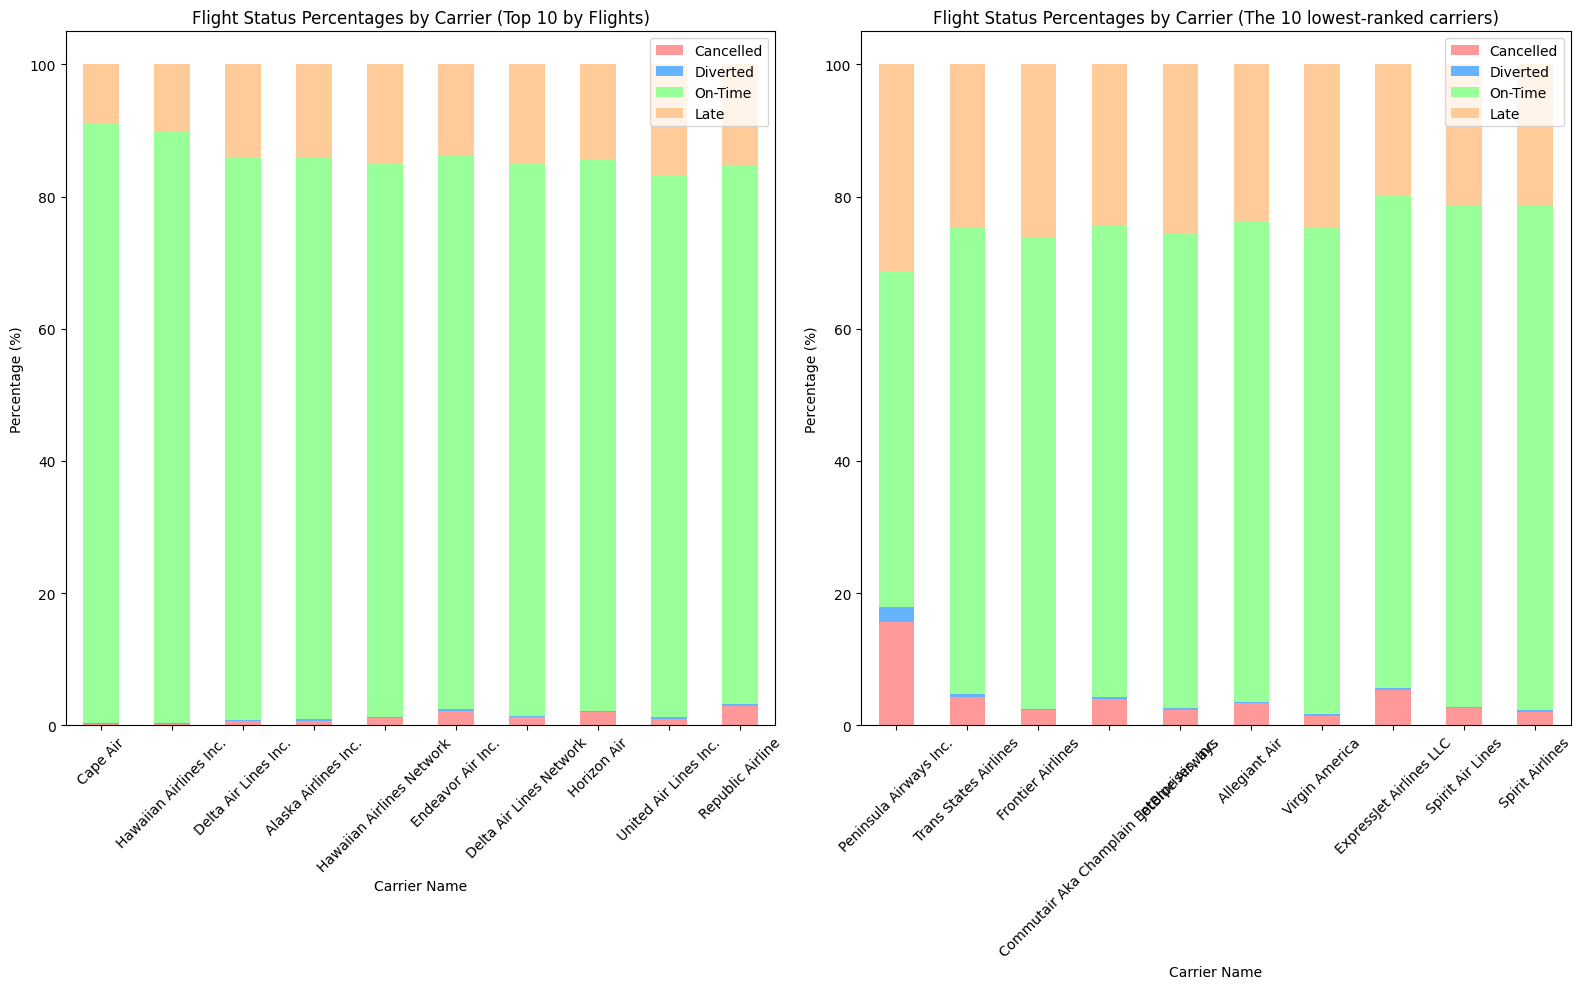

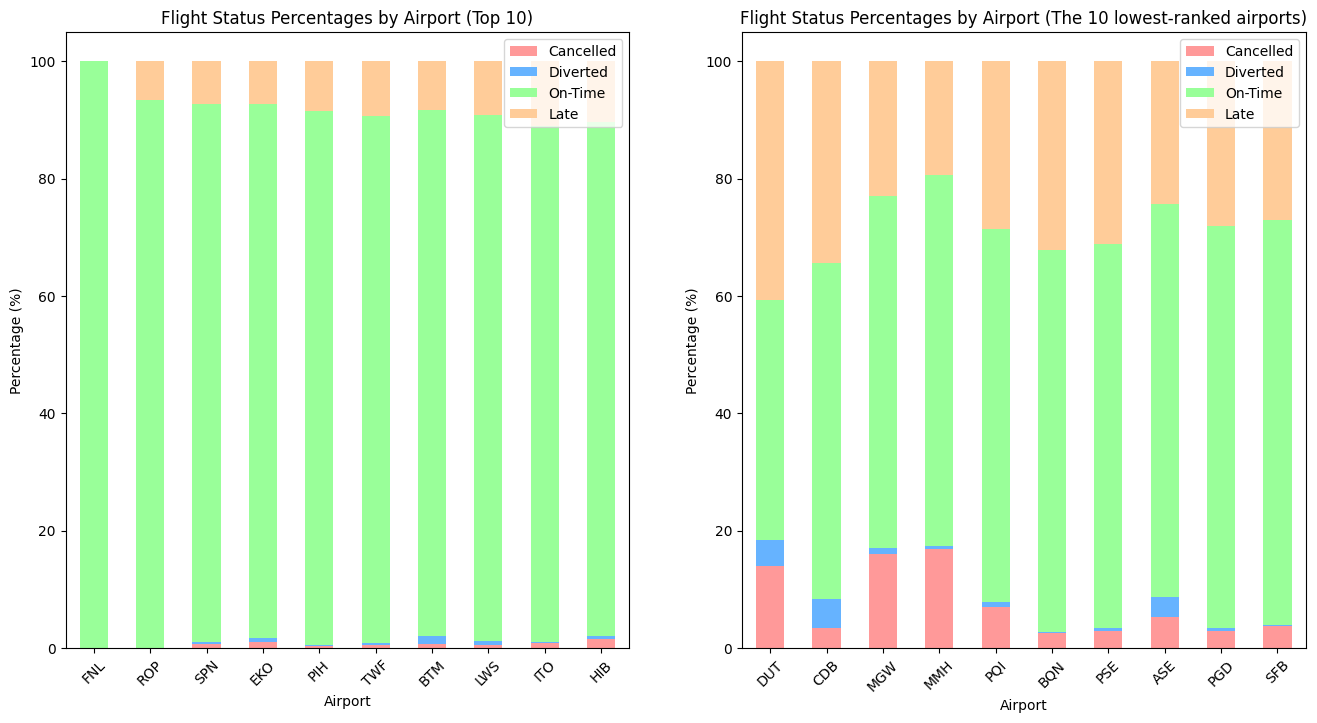

In [9]:
# Calculate top 10 carriers by total arrival flights
names_carriers = data.groupby('carrier_name')['arr_flights'].sum().index
carrier_data = data[data['carrier_name'].isin(names_carriers)]

# Calculate percentages for each status
carrier_grouped = carrier_data.groupby('carrier_name').agg({
    'arr_flights': 'sum',
    'arr_cancelled': 'sum',
    'arr_diverted': 'sum',
    'arr_del15': 'sum',
    'On-time': 'sum'
})

carrier_percent = carrier_grouped[['arr_cancelled', 'arr_diverted', 'On-time', 'arr_del15']].div(carrier_grouped['arr_flights'], axis=0) * 100
carrier_percent_top10 = carrier_percent.sort_values(by='On-time', ascending = False).head(10)
carrier_percent_low10 = carrier_percent.sort_values(by='On-time', ascending = True).head(10)

carrier_colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
carrier_labels = ['Cancelled', 'Diverted', 'On-Time', 'Late']

# Plot for carriers
fig_car, axes_car = plt.subplots(1, 2, figsize=(16, 10))

carrier_percent_top10.plot(kind='bar', stacked=True, color=carrier_colors, ax=axes_car[0])
axes_car[0].set_title('Flight Status Percentages by Carrier (Top 10 by Flights)')
axes_car[0].set_ylabel('Percentage (%)')
axes_car[0].set_xlabel('Carrier Name')
axes_car[0].tick_params(axis='x', rotation=45)
axes_car[0].legend(carrier_labels, loc='upper right')

carrier_percent_low10.plot(kind='bar', stacked=True, color=carrier_colors, ax=axes_car[1])
axes_car[1].set_title('Flight Status Percentages by Carrier (The 10 lowest-ranked carriers)')
axes_car[1].set_ylabel('Percentage (%)')
axes_car[1].set_xlabel('Carrier Name')
axes_car[1].tick_params(axis='x', rotation=45)
axes_car[1].legend(carrier_labels, loc='upper right')


plt.tight_layout()
plt.show()

# Calculate top 10 airports by total arrival flights
names_airports = data.groupby('airport')['arr_flights'].sum().index
airport_data = data[data['airport'].isin(names_airports)]

airport_grouped = airport_data.groupby('airport').agg({
    'arr_flights': 'sum',
    'arr_cancelled': 'sum',
    'arr_diverted': 'sum',
    'arr_del15': 'sum',
    'On-time': 'sum'
})

airport_percent = airport_grouped[['arr_cancelled', 'arr_diverted', 'On-time', 'arr_del15']].div(airport_grouped['arr_flights'], axis=0) * 100
airport_percent_top10 = airport_percent.sort_values(by='On-time', ascending = False).head(10)
airport_percent_low10 = airport_percent.sort_values(by='On-time', ascending = True).head(10)

airport_colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
airport_labels = ['Cancelled', 'Diverted', 'On-Time', 'Late']

# Plot for airports
fig_air, axes_air = plt.subplots(1, 2, figsize=(16, 8))

airport_percent_top10.plot(kind='bar', stacked=True, color=airport_colors, ax=axes_air[0])
axes_air[0].set_title('Flight Status Percentages by Airport (Top 10)')
axes_air[0].set_ylabel('Percentage (%)')
axes_air[0].set_xlabel('Airport')
axes_air[0].tick_params(axis='x', rotation=45)
axes_air[0].legend(airport_labels, loc='upper right')

airport_percent_low10.plot(kind='bar', stacked=True, color=airport_colors, ax=axes_air[1])
axes_air[1].set_title('Flight Status Percentages by Airport (The 10 lowest-ranked airports)')
axes_air[1].set_ylabel('Percentage (%)')
axes_air[1].set_xlabel('Airport')
axes_air[1].tick_params(axis='x', rotation=45)
axes_air[1].legend(airport_labels, loc='upper right')


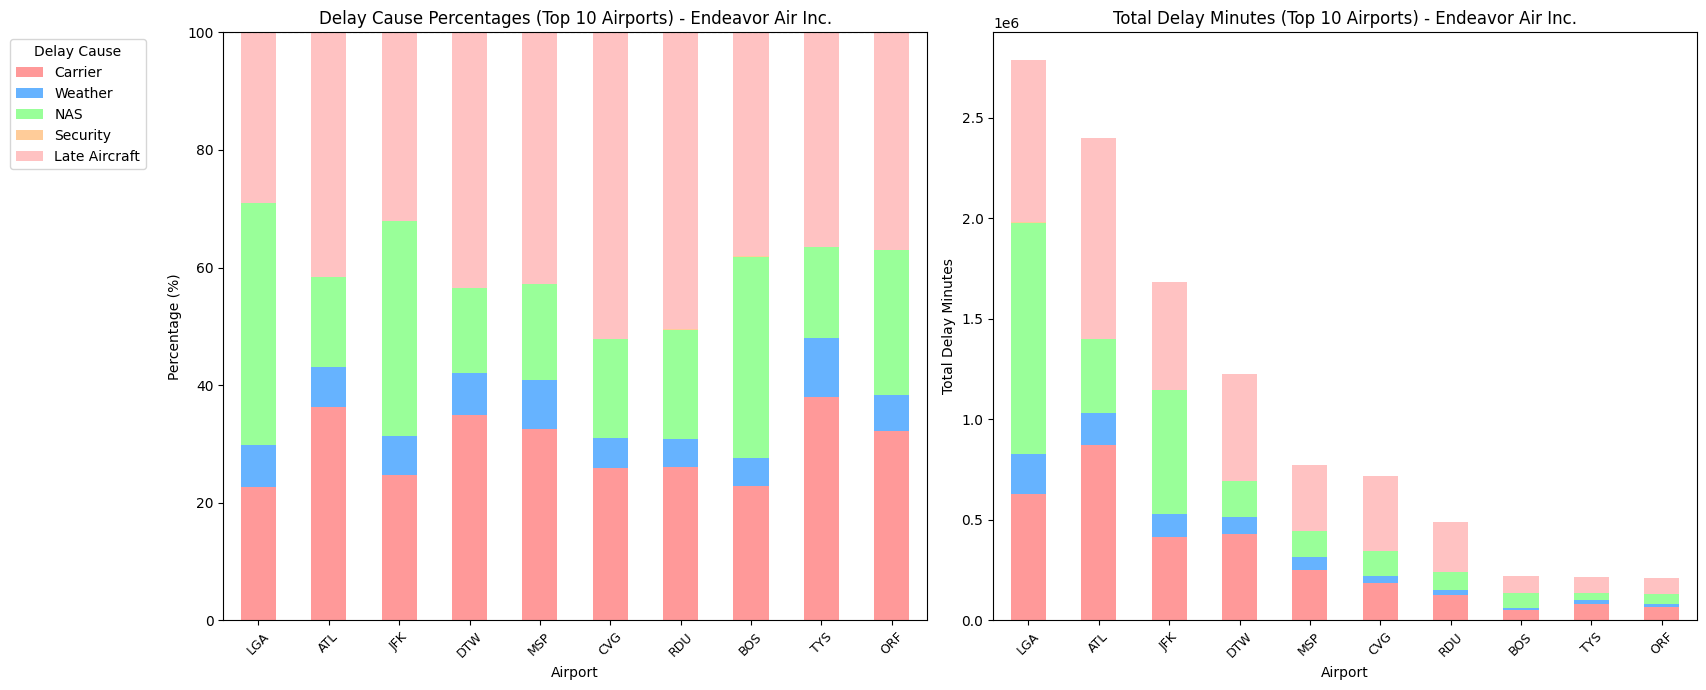

In [10]:
# Identify the carrier
worst_carrier_name = 'Endeavor Air Inc.'
worst_carrier_data = data[data['carrier_name'] == worst_carrier_name]
delay_minutes_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Define colors for the plot
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', "#FFC2C2"]
# Define labels for legend (in English)
cause_labels_en = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

# --- Calculations ---

# Group by airport and sum the delay minutes
carrier_airport_delays_total = worst_carrier_data.groupby('airport')[delay_minutes_cols].sum()

# Calculate the total delay minutes per airport (sum of rows)
carrier_airport_delays_total['total_delay'] = carrier_airport_delays_total.sum(axis=1)

# Sort by total delay minutes and select the top 10 airports
top10_airports_total = carrier_airport_delays_total.sort_values(by='total_delay', ascending=False).head(10)

# Calculate the percentages for these top 10 airports
carrier_airport_delays_percent = top10_airports_total[delay_minutes_cols].div(top10_airports_total['total_delay'], axis=0) * 100

# --- Plotting Side-by-Side ---

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased figure width

# --- Left Plot (Percentages) ---
carrier_airport_delays_percent.plot(kind='bar', stacked=True, color=colors, ax=axes[0])
axes[0].set_title(f'Delay Cause Percentages (Top 10 Airports) - {worst_carrier_name}')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Airport')
axes[0].tick_params(axis='x', rotation=45, labelsize=9, labelright=False) # Smaller labels
axes[0].legend(title='Delay Cause', labels=cause_labels_en, bbox_to_anchor=(-0.1, 1), loc='upper right') # Adjusted legend position
axes[0].set_ylim(0, 100)
axes[0].axhline(100, color='gray', linestyle='--', linewidth=0.8) # Optional line at 100%

# --- Right Plot (Total Minutes) ---
# Select only the delay cause columns for plotting
top10_airports_minutes = top10_airports_total[delay_minutes_cols]
top10_airports_minutes.plot(kind='bar', stacked=True, color=colors, ax=axes[1])
axes[1].set_title(f'Total Delay Minutes (Top 10 Airports) - {worst_carrier_name}')
axes[1].set_ylabel('Total Delay Minutes')
axes[1].set_xlabel('Airport')
axes[1].tick_params(axis='x', rotation=45, labelsize=9, labelright=False) # Smaller labels
axes[1].legend().set_visible(False) # Hide legend on the right plot (it's redundant)
# Optional: Format y-axis to show commas for thousands
# axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Adjust overall layout
plt.tight_layout(rect=[0.05, 0, 1, 1]) # Add some left margin for the legend
#plt.savefig('Carrier_DrillDown_SideBySide_en.png')
plt.show()

Heatmaps show correlation between different types of variables. In this plot we can see how different types of delays relates to each other. High values imply that reducing the incidence of one delay cause could have a measurable impact on the frequency or magnitude of the other.

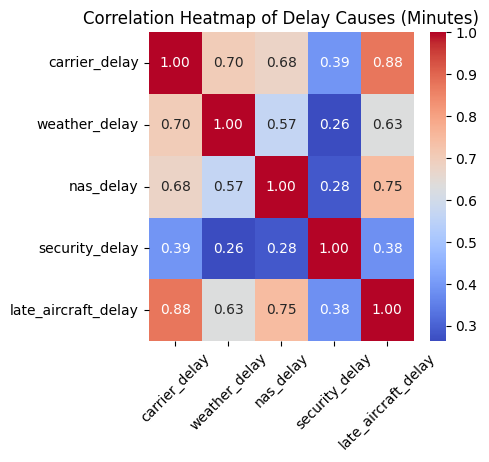

In [11]:
# Column selection
delay_minutes_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Correlation matrix
correlation_matrix = data[delay_minutes_cols].corr()
# Visualize the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Delay Causes (Minutes)')
plt.tight_layout()
plt.tick_params(axis='x', rotation=45)
# plt.savefig('Correlation_Heatmap.png')
plt.show()

## Train a prediction model

We are going to load data from all airports and carriers from Jan2024 to Jan2025. All this data will help us to define and train a machine learning model to predict delays on flights.

In [12]:
data_ML = pd.read_csv('Data/Airline_Delay_Cause.csv')
data_ML.info()
data_ML.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190335 entries, 0 to 190334
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 190335 non-null  int64  
 1   month                190335 non-null  int64  
 2   carrier              190335 non-null  object 
 3   carrier_name         190335 non-null  object 
 4   airport              190335 non-null  object 
 5   airport_name         190335 non-null  object 
 6   arr_flights          189990 non-null  float64
 7   arr_del15            189737 non-null  float64
 8   carrier_ct           189990 non-null  float64
 9   weather_ct           189990 non-null  float64
 10  nas_ct               189990 non-null  float64
 11  security_ct          189990 non-null  float64
 12  late_aircraft_ct     189990 non-null  float64
 13  arr_cancelled        189990 non-null  float64
 14  arr_diverted         189990 non-null  float64
 15  arr_delay        

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,190335.000000,190335.000000,189990.000000,189737.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000,189990.000000
mean,2020.390969,6.438674,321.096668,58.350870,18.542072,2.059380,16.805769,0.149036,20.716906,6.602095,0.760572,3932.901784,1355.701200,220.237991,814.166556,7.036012,1535.744787
std,2.439395,3.488701,920.132463,167.154599,48.363146,7.212806,56.169862,0.717362,66.598795,40.621291,3.406992,12576.717863,4336.193396,869.704989,3198.832155,40.952528,5240.233800
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,39.000000,5.000000,1.930000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,286.000000,89.000000,0.000000,27.000000,0.000000,53.000000
50%,2020.000000,6.000000,87.000000,15.000000,5.280000,0.220000,3.240000,0.000000,4.200000,1.000000,0.000000,899.000000,317.000000,12.000000,123.000000,0.000000,283.000000
75%,2022.000000,9.000000,211.000000,39.000000,14.420000,1.630000,9.590000,0.000000,12.930000,3.000000,1.000000,2555.000000,985.000000,134.000000,395.000000,0.000000,972.000000
max,2025.000000,12.000000,21977.000000,5544.000000,1886.580000,325.410000,1884.420000,58.690000,2588.130000,4951.000000,192.000000,648300.000000,321792.000000,64550.000000,139958.000000,3760.000000,279153.000000


The model will utilize only month, carrier, and airport as predictive features, as this is the information available beforehand. The target variable for this prediction is the 'On-time flight percentage'

First we are going to convert months into periodic variables. Doing this can help the model to understand that January and December are equally close than June and July

In [13]:
data_ML['month_sin'] = np.sin(2 * np.pi * data_ML['month']/12)
data_ML['month_cos'] = np.cos(2 * np.pi * data_ML['month']/12)

In [14]:
#Convert into categorical data types
all_carriers = data_ML['carrier'].unique()
all_airports = data_ML['airport'].unique()

carrier_cat_type = pd.api.types.CategoricalDtype(categories=all_carriers, ordered=False)
airport_cat_type = pd.api.types.CategoricalDtype(categories=all_airports, ordered=False)

data_ML['carrier'] = data_ML['carrier'].astype(carrier_cat_type)
data_ML['airport'] = data_ML['airport'].astype(airport_cat_type)

data_ML['On-time'] = data_ML['arr_flights'] - data_ML['arr_cancelled'] - data_ML['arr_diverted'] - data_ML['arr_del15']
data_ML['On-time_percentage'] = data_ML['On-time'] / data_ML['arr_flights'] * 100
#Drop missing values
data_ML.dropna(subset=['month', 'carrier', 'airport', 'On-time_percentage'], inplace=True)

#Set features and target variables
X = data_ML[['month_sin', 'month_cos', 'carrier', 'airport']]
y = data_ML['On-time_percentage']

In [15]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0)

models = {
    "model1" : XGBRegressor(enable_categorical = True, random_state=0),
    "model2" : XGBRegressor(enable_categorical = True, n_estimators=400, learning_rate=0.03, random_state=0),
    "model3" : XGBRegressor(enable_categorical = True, n_estimators=500, learning_rate=0.05 , random_state=0),
    "model4" : XGBRegressor(enable_categorical = True, n_estimators=700, learning_rate=0.005, random_state=0),
    "model5" : XGBRegressor(enable_categorical = True, n_estimators=1000, learning_rate=0.01, random_state=0),
}

In [16]:
best_score = -float('inf')
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f'{name} - Test Score: {score:.4f}')
    if score > best_score:
        best_score = score
        best_model_name = name

print(f'The best model is: {best_model_name} with the score of {best_score:.4f}')
model = models[best_model_name]

model1 - Test Score: 0.1401
model2 - Test Score: 0.1611
model3 - Test Score: 0.1459
model4 - Test Score: 0.1574
model5 - Test Score: 0.1613
The best model is: model5 with the score of 0.1613


As the low scores show, the model cannot find solid patterns. This is absolutely normal, because we are giving poor data. In order to increase score more variables should be considered


Nevertheless we are going to use the model in a dataframe with data from June and July of 2025 to show an application of the model.

In [17]:
data = pd.read_csv('Data/Airline_Delay_Cause_Newest.csv')
data['month_sin'] = np.sin(2 * np.pi * data_ML['month']/12)
data['month_cos'] = np.cos(2 * np.pi * data_ML['month']/12)
data['carrier'] = data['carrier'].astype('category')
data['airport'] = data['airport'].astype('category')
X = data[['month_sin', 'month_cos', 'carrier', 'airport']]
y = model.predict(X)

In [19]:
data['On-time'] = data['arr_flights'] - data['arr_cancelled'] - data['arr_diverted'] - data['arr_del15']
data['On-time_percentage'] = data['On-time'] / data['arr_flights'] * 100
error = np.abs(data['On-time_percentage']- y)
print(f'Mean absolute error of the predictions: {np.mean(error):.4f} %')
data['On-time_percentage-predicted'] = y
data[['month', 'carrier', 'airport', 'On-time_percentage' ,'On-time_percentage-predicted']].head(10)

Mean absolute error of the predictions: 11.1501 %


,month,carrier,airport,On-time_percentage,On-time_percentage-predicted
0,6,9E,ABE,66.666667,84.402237
1,6,9E,ABY,80.000000,87.838600
2,6,9E,AEX,63.768116,80.966286
3,6,9E,AGS,66.451613,85.028938
4,6,9E,ALB,61.627907,80.483063
5,6,9E,ATL,69.610390,82.986145
6,6,9E,AUS,67.777778,78.815346
7,6,9E,AVL,56.578947,84.112633
8,6,9E,BGR,68.686869,78.888870
9,6,9E,BHM,53.284672,80.016212
